In [ ]:
!pip install gdown segmentation-models -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.7 MB/s eta 0:00:00


In [1]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, optimizers, losses, callbacks
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG19, MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
from tqdm import tqdm

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

TensorFlow: 2.19.0
Keras: 3.10.0


In [ ]:
print("Verificando GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs encontradas: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No se encontraron GPUs. Usando CPU.")

Verificando GPU...
GPUs encontradas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Descargar datos
!gdown --id 1sHYkAuE-5Z0A1NBFxblvlQ8o8bZZuDyl
!unzip -q Preprocesado_Pix2Pix.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1sHYkAuE-5Z0A1NBFxblvlQ8o8bZZuDyl
From (redirected): https://drive.google.com/uc?id=1sHYkAuE-5Z0A1NBFxblvlQ8o8bZZuDyl&confirm=t&uuid=b7113108-847b-44ca-a354-9383d4c6ab7c
To: /content/Preprocesado_Pix2Pix.zip
100% 1.04G/1.04G [00:19<00:00, 52.3MB/s]


In [3]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
USE_TRANSFER_LEARNING = True
BACKBONE = 'efficientnetb0'
FREEZE_ENCODER_INITIAL = True
UNFREEZE_AT_EPOCH = 20
EPOCHS = 100
BATCH_SIZE = 8
IMG_SIZE = 256
LAMBDA_L1 = 100
LAMBDA_PERCEPTUAL = 10
CHECKPOINT_INTERVAL = 25

PATH = 'Preprocesado_Pix2Pix/'
TRAIN_A_DIR = os.path.join(PATH, 'train_A')
OUTPUT_DIR = 'Resultados_TL_TF'
CHECKPOINT_DIR = '/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-TL'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"CONFIGURACIÓN DEL ENTRENAMIENTO")
print(f"{'='*70}")
print(f"Backbone:              {BACKBONE}")
print(f"Transfer Learning:     {USE_TRANSFER_LEARNING}")
print(f"Encoder inicial:       {'Congelado' if FREEZE_ENCODER_INITIAL else 'Entrenable'}")
print(f"Descongelar en época:  {UNFREEZE_AT_EPOCH}")
print(f"Lambda L1:             {LAMBDA_L1}")
print(f"Lambda Perceptual:     {LAMBDA_PERCEPTUAL}")
print(f"Epochs totales:        {EPOCHS}")
print(f"Checkpoints:           {CHECKPOINT_DIR}")
print(f"{'='*70}\n")


CONFIGURACIÓN DEL ENTRENAMIENTO
Backbone:              efficientnetb0
Transfer Learning:     True
Encoder inicial:       Congelado
Descongelar en época:  20
Lambda L1:             100
Lambda Perceptual:     10
Epochs totales:        100
Checkpoints:           /content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-TL



In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.data.Dataset.list_files(TRAIN_A_DIR + '/*.jpg')

def load_and_preprocess(path):
    real_path = tf.strings.regex_replace(path, "train_A", "train_B")

    inp = tf.io.read_file(path)
    inp = tf.image.decode_jpeg(inp, channels=3)
    real = tf.io.read_file(real_path)
    real = tf.image.decode_jpeg(real, channels=3)

    # Resize directo a 256 (elimina el 286→crop que mata velocidad)
    inp = tf.image.resize(inp, [IMG_SIZE, IMG_SIZE])
    real = tf.image.resize(real, [IMG_SIZE, IMG_SIZE])

    # Flip aleatorio rápido
    if tf.random.uniform(()) > 0.5:
        inp = tf.image.flip_left_right(inp)
        real = tf.image.flip_left_right(real)

    inp = tf.cast(inp, tf.float32) / 127.5 - 1
    real = tf.cast(real, tf.float32) / 127.5 - 1

    return inp, real

train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

In [7]:
def get_generator():
    inputs = Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    if BACKBONE == 'efficientnetb0':
        backbone = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
        skips = ['block2a_expand_activation', 'block3a_expand_activation',
                 'block4a_expand_activation', 'block6a_expand_activation']
        filters = [512, 256, 128, 64]
    elif BACKBONE == 'resnet50':
        backbone = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
        skips = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out']
        filters = [512, 256, 128, 64]


    backbone.trainable = not FREEZE_ENCODER_INITIAL

    skip_connections = [backbone.get_layer(name).output for name in skips]
    x = backbone.output  # bottleneck

    for f, skip in zip(filters, reversed(skip_connections)):
        x = layers.UpSampling2D()(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        skip = layers.Resizing(x.shape[1], x.shape[2])(skip) if skip.shape[1] != x.shape[1] else skip
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(3, 1, activation='tanh', padding='same')(x)

    model = Model(inputs, x, name='generator')
    return model, backbone

generator, backbone_model = get_generator()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
def get_discriminator():
    inp = Input([IMG_SIZE, IMG_SIZE, 3])
    tar = Input([IMG_SIZE, IMG_SIZE, 3])
    x = layers.Concatenate()([inp, tar])

    x = layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(512, 4, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(1, 4, strides=1, padding='same')(x)

    return Model([inp, tar], x)

discriminator = get_discriminator()

In [9]:
# Pérdida perceptual (VGG19)
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False
perceptual_layers = ['block3_conv3', 'block4_conv3']
feature_extractor = Model(vgg.input, [vgg.get_layer(n).output for n in perceptual_layers])

def perceptual_loss(y_true, y_pred):
    y_true = (y_true + 1) / 2
    y_pred = (y_pred + 1) / 2
    a = feature_extractor(y_true)
    b = feature_extractor(y_pred)
    return tf.add_n([tf.reduce_mean(tf.abs(a_i - b_i)) for a_i, b_i in zip(a, b)])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [10]:
def discriminator_loss(real_output, fake_output):
    """
    Pérdida del discriminador con label smoothing (0.9 en vez de 1.0).
    Esto evita que el discriminador sea demasiado confiado y colapse el entrenamiento.
    """
    real_loss = losses.BinaryCrossentropy(from_logits=True)(
        tf.ones_like(real_output) * 0.9,   # Label smoothing: 0.9 en vez de 1.0
        real_output
    )
    fake_loss = losses.BinaryCrossentropy(from_logits=True)(
        tf.zeros_like(fake_output),        # 0.0 para fake
        fake_output
    )
    total_disc_loss = real_loss + fake_loss
    return total_disc_loss

In [11]:
gen_opt = optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = optimizers.Adam(2e-4, beta_1=0.5)

In [12]:
ckpt = tf.train.Checkpoint(
    generator=generator,
    discriminator=discriminator,
    gen_opt=gen_opt,
    disc_opt=disc_opt
)
ckpt_manager = tf.train.CheckpointManager(ckpt, CHECKPOINT_DIR, max_to_keep=5)

In [13]:
@tf.function
def train_step(inp, tar):
    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        fake = generator(inp, training=True)

        real_out = discriminator([inp, tar], training=True)
        fake_out = discriminator([inp, fake], training=True)

        # === GENERATOR LOSSES (ya las tenías calculadas) ===
        g_loss_gan = losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(fake_out), fake_out)
        g_loss_l1 = tf.reduce_mean(tf.abs(tar - fake))
        g_loss_perc = perceptual_loss(tar, fake)
        g_loss_total = g_loss_gan + LAMBDA_L1 * g_loss_l1 + LAMBDA_PERCEPTUAL * g_loss_perc

        # === DISCRIMINATOR LOSS ===
        d_loss = discriminator_loss(real_out, fake_out)

    # Gradientes y aplicación
    g_grads = g_tape.gradient(g_loss_total, generator.trainable_variables)
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    gen_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    disc_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # Devolvemos todo lo necesario para el resumen (¡gratis!)
    return (g_loss_total,
            g_loss_gan,
            g_loss_l1,
            # ahora sí son tensores, pero .numpy() fuera
            g_loss_perc,
            d_loss)

In [ ]:
epoch_g_total_list = []
epoch_g_gan_list   = []
epoch_g_l1_list    = []
epoch_g_perc_list  = []
epoch_d_list       = []
best_gen_loss = np.inf

test_inp, test_tar = next(iter(train_dataset.take(1)))

for epoch in range(EPOCHS):
    start_time = time.time()

    # Reiniciamos listas cada época
    epoch_g_total_list.clear()
    epoch_g_gan_list.clear()
    epoch_g_l1_list.clear()
    epoch_g_perc_list.clear()
    epoch_d_list.clear()

    # Descongelar encoder en la época configurada
    if USE_TRANSFER_LEARNING and epoch + 1 == UNFREEZE_AT_EPOCH:  # epoch empieza en 0
        print("\n" + "="*60)
        print("DESCONGELANDO ENCODER PARA FINE-TUNING")
        print("="*60)
        backbone_model.trainable = True
        gen_opt = keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5)
        ckpt.gen_opt = gen_opt

    progbar = tqdm(train_dataset, desc=f"Época {epoch+1}/{EPOCHS}")
    for inp, tar in progbar:
        # Entrenamos normalmente
        g_total, g_gan, g_l1, g_perc, d_loss = train_step(inp, tar)

        # Guardamos directamente (sin volver a calcular nada)
        epoch_g_total_list.append(g_total.numpy())
        epoch_g_gan_list.append(g_gan.numpy())
        epoch_g_l1_list.append(g_l1.numpy())
        epoch_g_perc_list.append(g_perc.numpy())
        epoch_d_list.append(d_loss.numpy())

        progbar.set_postfix({"G": f"{g_total.numpy():.4f}", "D": f"{d_loss.numpy():.4f}"})

    # ========================= RESUMEN DE ÉPOCA =========================
    epoch_time = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"ÉPOCA {epoch+1}/ {EPOCHS} COMPLETADA - Tiempo: {epoch_time:.2f}s ({epoch_time/60:.2f} min)")
    print(f"{'='*70}")
    print(f"Discriminador Loss     → {np.mean(epoch_d_list):.6f}")
    print(f"Generador Total Loss   → {np.mean(epoch_g_total_list):.6f}")
    print(f"   ├─ GAN Loss         → {np.mean(epoch_g_gan_list):.6f}")
    print(f"   ├─ L1 Loss          → {np.mean(epoch_g_l1_list):.6f}")
    print(f"   └─ Perceptual Loss  → {np.mean(epoch_g_perc_list):.6f}")
    print(f"{'='*70}\n")

    # Guardar mejor modelo según pérdida total del generador
    current_gen_loss = np.mean(epoch_g_total_list)
    if current_gen_loss < best_gen_loss:
        best_gen_loss = current_gen_loss
        generator.save(f"{CHECKPOINT_DIR}/best_generator.keras")
        print(f"MEJOR MODELO GUARDADO → Loss: {best_gen_loss:.6f}")

    # Imagen de muestra
    pred = generator(test_inp, training=False)
    plt.figure(figsize=(15,5))
    for i, img in enumerate([test_inp[0], test_tar[0], pred[0]]):
        plt.subplot(1,3,i+1)
        plt.imshow(img * 0.5 + 0.5)
        plt.axis('off')
    plt.savefig(f"{OUTPUT_DIR}/epoch_{epoch+1:03d}.jpg", dpi=200, bbox_inches='tight')
    plt.close()

    # Checkpoint cada N épocas
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0 or (epoch + 1) == EPOCHS:
        ckpt_manager.save()
        print(f"Checkpoint guardado en época {epoch+1}")

Época 1/100: 100%|██████████| 245/245 [00:47<00:00,  5.14it/s, G=41.6727, D=1.2505]



ÉPOCA 1/ 100 COMPLETADA - Tiempo: 47.65s (0.79 min)
Discriminador Loss     → 0.617556
Generador Total Loss   → 49.775215
   ├─ GAN Loss         → 2.803938
   ├─ L1 Loss          → 0.232418
   └─ Perceptual Loss  → 2.372951

MEJOR MODELO GUARDADO → Loss: 49.775215


Época 2/100: 100%|██████████| 245/245 [00:47<00:00,  5.18it/s, G=54.0614, D=3.8729]



ÉPOCA 2/ 100 COMPLETADA - Tiempo: 47.30s (0.79 min)
Discriminador Loss     → 0.612007
Generador Total Loss   → 49.712318
   ├─ GAN Loss         → 3.032775
   ├─ L1 Loss          → 0.234670
   └─ Perceptual Loss  → 2.321257

MEJOR MODELO GUARDADO → Loss: 49.712318


Época 3/100: 100%|██████████| 245/245 [00:47<00:00,  5.15it/s, G=61.2488, D=0.3987]


...


ÉPOCA 98/ 100 COMPLETADA - Tiempo: 47.36s (0.79 min)
Discriminador Loss     → 0.326916
Generador Total Loss   → 50.256428
   ├─ GAN Loss         → 8.543286
   ├─ L1 Loss          → 0.194324
   └─ Perceptual Loss  → 2.228072



Época 99/100: 100%|██████████| 245/245 [00:47<00:00,  5.17it/s, G=55.7935, D=0.3265]



ÉPOCA 99/ 100 COMPLETADA - Tiempo: 47.37s (0.79 min)
Discriminador Loss     → 0.326379
Generador Total Loss   → 50.420658
   ├─ GAN Loss         → 8.873372
   ├─ L1 Loss          → 0.193631
   └─ Perceptual Loss  → 2.218420



Época 100/100: 100%|██████████| 245/245 [00:47<00:00,  5.17it/s, G=47.8428, D=0.3263]



ÉPOCA 100/ 100 COMPLETADA - Tiempo: 47.39s (0.79 min)
Discriminador Loss     → 0.326096
Generador Total Loss   → 50.569977
   ├─ GAN Loss         → 9.059567
   ├─ L1 Loss          → 0.193093
   └─ Perceptual Loss  → 2.220114

Checkpoint guardado en época 100


In [ ]:
# Guardar modelo final compatible con Keras 3
generator.save(f"{CHECKPOINT_DIR}/generator_final.keras")
print("Modelo final guardado como .keras")

Modelo final guardado como .keras


In [17]:
loaded_generator = tf.keras.models.load_model(
    f"{CHECKPOINT_DIR}/generator_final.keras",
    custom_objects={'perceptual_loss': perceptual_loss}
)
print("Modelo 'generator_final.keras' cargado exitosamente.")

Modelo 'generator_final.keras' cargado exitosamente.


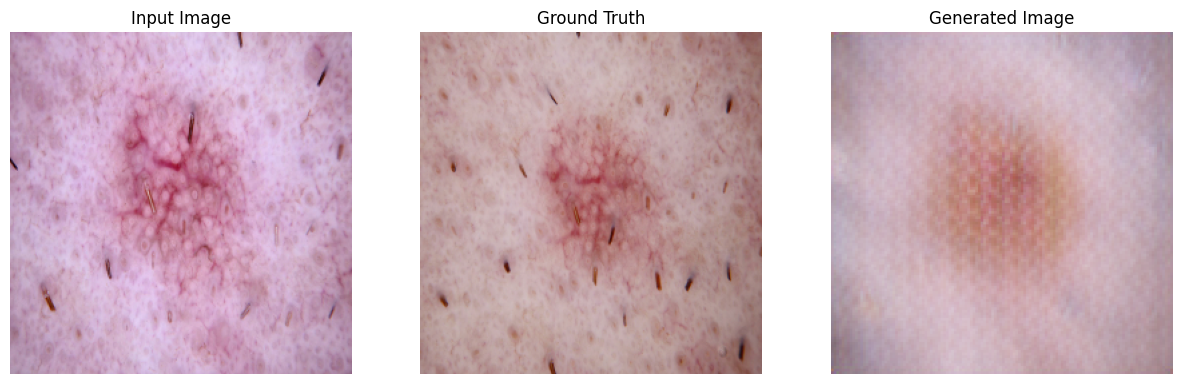

In [18]:
def predict_and_plot(input_image, real_image, model, num_examples=1):
    prediction = model(input_image, training=False)

    plt.figure(figsize=(15, 5 * num_examples))

    for i in range(num_examples):
        display_list = [input_image[i], real_image[i], prediction[i]]
        title = ['Input Image', 'Ground Truth', 'Generated Image']

        for j in range(3):
            plt.subplot(num_examples, 3, i * 3 + j + 1)
            plt.title(title[j])
            # Getting the pixel values in the range [0, 1] to plot it.
            plt.imshow(display_list[j] * 0.5 + 0.5)
            plt.axis('off')
    plt.show()


for inp, tar in train_dataset.take(1):
    predict_and_plot(inp, tar, loaded_generator, num_examples=1)

In [19]:
#Cargar modelo sin transfer Learning
CHECKPOINT_DIR_sim = '/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple'
loaded_generator_base = tf.keras.models.load_model(
    f"{CHECKPOINT_DIR_sim}/generator_final.keras"
)
print("Modelo 'generator_final.keras' cargado exitosamente.")

Modelo 'generator_final.keras' cargado exitosamente.


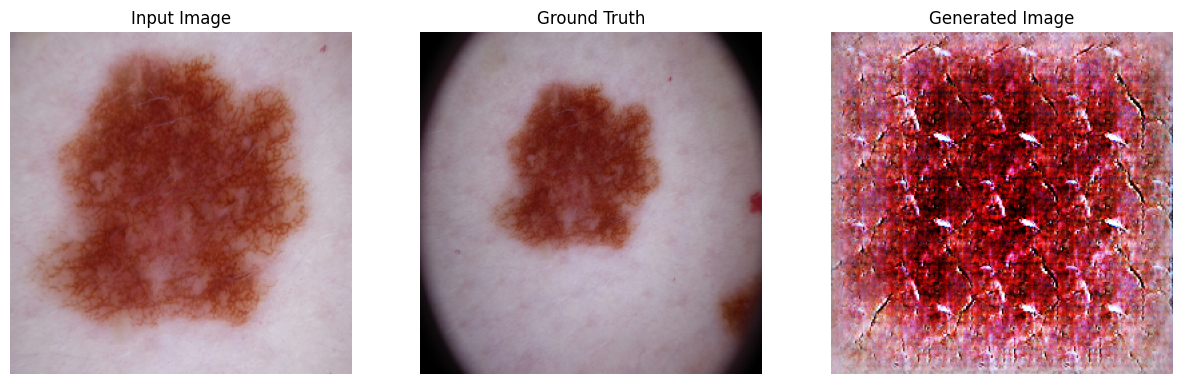

In [22]:
for inp, tar in train_dataset.take(1):
    predict_and_plot(inp, tar, loaded_generator_base, num_examples=1)